# End-to-End Supervised Learning Workflow: HDB Resale Price Prediction with CatBoost

**Goal**: Build a supervised regression workflow to predict `resale_price` from the training dataset using `CatBoostRegressor`.

**Scenario**

The dataset contains flat attributes, transaction timing, address/location signals, nearby amenities, schools, and transport features. The target variable is `resale_price`, so this is a supervised regression problem evaluated with RMSE.

**Workflow**

1. Load the sample submission, test data, and training data.
2. Define sklearn-compatible feature transformers for transaction timing, lease/age/storey features, flat-type ordinal encoding, distance/accessibility features, categorical combinations, geohash spatial indexing, and HDBSCAN geo-cluster features.
3. Convert each latitude/longitude pair (flat, MRT, bus stop, primary school, secondary school) into geohash buckets at precisions 5, 6, 7 (coarse → fine neighborhood labels). S2 retired as redundant with geohash.
4. Split labeled training data into features (`X`) and target (`Y`).
5. Define preprocessing groups: dropped identifiers/raw coordinate columns, regular categorical columns, spatial-index categorical columns. Numerics passed through raw — CatBoost is tree-based and does not need scaling. Old scaler code retained, commented out, at the end of the notebook for reference.
6. Build a reusable pipeline that creates engineered features, drops unused/raw coordinate columns, imputes categorical missing values, and passes both numerics and categoricals to CatBoost (categoricals via `cat_features` for native handling).
7. Create a held-out test split (`X_test`) AND a tuning validation split (`X_val`) carved from `X_train`. `X_test` is touched exactly once at the end of tuning for an honest generalization estimate. `X_val` is used as `eval_set` during hyperparameter search for early stopping. This avoids leaking the held-out test set.
8. Step A — fit a baseline CatBoost on `X_train`, evaluate on `X_test`.
9. Step B — 10-fold CV on `X_train` as a stability benchmark (informational only; does not select a model).
10. Step C — randomized hyperparameter search over `X_tr` with early stopping on `X_val`; capture best params and `best_iteration_`. Refit on full `X_train` with best params, evaluate once on `X_test`.
11. Step D — re-derive iteration count for full-data fit (`final_iter ≈ 1.1 × best_iter`), refit on all labeled data (`X_train ∪ X_test`), predict the Kaggle test data, save the model, and write the submission CSV.


## 1. Imports and Data Loading

First, import the libraries used throughout the workflow and load the training dataset. The `id` column is used as the dataframe index.


In [1]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor, Pool
import geohash2
import hdbscan
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, ParameterSampler, train_test_split
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 120)


In [2]:
# load submission format
df_sub = pd.read_csv('data/sample_sub_reg.csv')

df_sub.shape
df_sub.head()


,Id,Predicted
0,114982,500000
1,95653,500000
2,40303,500000
3,109506,500000
4,100149,500000


In [3]:
# load test dataset
df_test = pd.read_csv('data/test.csv')

df_test.shape
df_test.head()

/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_39966/3630737951.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('data/test.csv')


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,114982,2012-11,YISHUN,4 ROOM,173,YISHUN AVE 7,07 TO 09,84.0,Simplified,1987,2012,11,8,7,9,8,4 ROOM Simplified,"173, YISHUN AVE 7",904.176,34,12,1986,Y,Y,N,N,N,132,0,0,0,92,40,0,0,0,0,0,0,0,760173,1.437066,103.831121,Yishun,877.431572,NaN,2.0,4.0,687.576779,NaN,1.0,1.0,56,123,686.660434,Canberra,0,0,1.443077,103.829703,75.683952,Blk 174,1.437558,103.831591,426.467910,Ahmad Ibrahim Primary School,92,0,1.433681,103.832924,156.322353,Ahmad Ibrahim Secondary School,218,0,1.436235,103.829987
1,95653,2019-08,JURONG WEST,5 ROOM,986C,JURONG WEST ST 93,04 TO 06,112.0,Premium Apartment,2008,2019,8,5,4,6,5,5 ROOM Premium Apartment,"986C, JURONG WEST ST 93",1205.568,13,14,2002,Y,N,N,N,N,53,0,0,0,28,25,0,0,0,0,0,0,0,643986,1.336957,103.695668,Jurong West,534.037705,NaN,1.0,3.0,2122.346226,NaN,NaN,NaN,72,94,169.478175,Pioneer,0,0,1.337343,103.697143,88.993058,Blk 653B,1.336491,103.696319,439.756851,Jurong West Primary School,45,0,1.339244,103.698896,739.371688,Jurong West Secondary School,199,0,1.335256,103.702098
2,40303,2013-10,ANG MO KIO,3 ROOM,534,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,2013,10,8,7,9,8,3 ROOM New Generation,"534, ANG MO KIO AVE 10",731.952,41,12,1979,Y,N,N,N,N,218,0,0,191,22,1,1,0,0,0,0,3,0,560534,1.374058,103.854168,Ang Mo Kio,817.050453,NaN,2.0,3.0,152.287621,1.0,3.0,11.0,50,100,694.220448,Ang Mo Kio,1,0,1.369465,103.849939,86.303575,Blk 532,1.374255,103.854919,355.882207,Jing Shan Primary School,36,0,1.371893,103.851811,305.071191,Anderson Secondary School,245,0,1.374242,103.851430
3,109506,2017-10,WOODLANDS,4 ROOM,29,MARSILING DR,01 TO 03,97.0,New Generation,1979,2017,10,2,1,3,2,4 ROOM New Generation,"29, MARSILING DR",1044.108,42,14,1976,Y,N,N,N,N,104,0,0,0,104,0,0,0,0,0,0,0,0,731029,1.442748,103.772922,Woodlands,1272.737194,NaN,NaN,3.0,501.892158,NaN,1.0,2.0,52,112,1117.203587,Marsiling,0,0,1.432757,103.773982,108.459039,Blk 32,1.443650,103.773295,929.744711,Marsiling Primary School,54,0,1.434423,103.773698,433.454591,Woodlands Secondary School,188,0,1.439183,103.774499
4,100149,2016-08,BUKIT BATOK,4 ROOM,170,BT BATOK WEST AVE 8,16 TO 18,103.0,Model A,1985,2016,8,17,16,18,17,4 ROOM Model A,"170, BT BATOK WEST AVE 8",1108.692,36,25,1985,Y,N,N,N,N,144,0,0,0,48,96,0,0,0,0,0,0,0,650170,1.346556,103.740101,Bukit Batok,1070.963675,NaN,NaN,5.0,437.593564,1.0,2.0,2.0,60,87,987.976010,Chinese Garden,0,0,1.342441,103.732225,113.645431,Blk 169,1.346899,103.741064,309.926934,Princess Elizabeth Primary School,40,0,1.349195,103.741000,217.295361,Bukit Batok Secondary School,223,0,1.348351,103.740873


In [4]:
# Load the training dataset.
df = pd.read_csv('data/train.csv')

df.shape

/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_39966/3207937961.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv')


(150634, 77)

## 2. Feature Engineering Inside the Pipeline

Define feature engineering as a sklearn transformer so the model can receive raw data at both training time and prediction time. The transformer learns the first transaction month during `fit`, then creates transaction timing, lease, age, flat-type ordinal, and storey-ratio features during every `transform`.


In [5]:
class TransactionDateFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, transaction_col='Tranc_YearMonth'):
        self.transaction_col = transaction_col
        self.flat_type_ordinal_map = {
            '1 ROOM': 1,
            '2 ROOM': 2,
            '3 ROOM': 3,
            '4 ROOM': 4,
            '5 ROOM': 5,
            'EXECUTIVE': 6,
            'MULTI-GENERATION': 7,
            'MULTI GENERATION': 7,
        }
        self.engineered_features = [
            'days_from_first_transaction',
            'month_sin',
            'month_cos',
            'transaction_quarter',
            'remaining_lease',
            'property_age_at_sale',
            'is_new_flat',
            'is_old_flat',
            'flat_type_ordinal',
            'storey_mid_ratio',
            'log_mrt_dist',
            'log_mall_dist',
            'log_hawker_dist',
            'log_bus_dist',
            'log_pri_sch_dist',
            'log_sec_sch_dist',
            'accessibility_score',
            'mrt_walkable',
            'bus_walkable',
            'mall_walkable',
            'hawker_walkable',
            'pri_school_walkable',
            'sec_school_walkable',
            'integrated_transport_access',
            'town_full_flat_type',
            'block_street_name',
            'street_name_pri_sch_name',
            'street_name_sec_sch_name',
        ]

    def fit(self, X, y=None):
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        self.first_transaction_date_ = transaction_dates.min()
        return self

    def transform(self, X):
        X = X.copy()
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        trans_year = pd.to_numeric(X['Tranc_Year'], errors='coerce')
        trans_month = pd.to_numeric(X['Tranc_Month'], errors='coerce')
        lease_commence_date = pd.to_numeric(X['lease_commence_date'], errors='coerce')
        year_completed = pd.to_numeric(X['year_completed'], errors='coerce')
        mid_storey = pd.to_numeric(X['mid_storey'], errors='coerce')
        max_floor_lvl = pd.to_numeric(X['max_floor_lvl'], errors='coerce')
        mrt_distance = pd.to_numeric(X['mrt_nearest_distance'], errors='coerce')
        mall_distance = pd.to_numeric(X['Mall_Nearest_Distance'], errors='coerce')
        hawker_distance = pd.to_numeric(X['Hawker_Nearest_Distance'], errors='coerce')
        bus_distance = pd.to_numeric(X['bus_stop_nearest_distance'], errors='coerce')
        pri_sch_distance = pd.to_numeric(X['pri_sch_nearest_distance'], errors='coerce')
        sec_sch_distance = pd.to_numeric(X['sec_sch_nearest_dist'], errors='coerce')

        X['days_from_first_transaction'] = (
            transaction_dates - self.first_transaction_date_
        ).dt.days

        X['month_sin'] = np.sin(2 * np.pi * trans_month / 12)
        X['month_cos'] = np.cos(2 * np.pi * trans_month / 12)
        X['transaction_quarter'] = np.ceil(trans_month / 3)
        X['remaining_lease'] = 99 - (trans_year - lease_commence_date)
        X['property_age_at_sale'] = trans_year - year_completed
        X['is_new_flat'] = (X['property_age_at_sale'] <= 6).astype(int)
        X['is_old_flat'] = (X['remaining_lease'] <= 60).astype(int)
        X['flat_type_ordinal'] = (
            X['flat_type']
            .astype('string')
            .str.upper()
            .map(self.flat_type_ordinal_map)
        )
        X['storey_mid_ratio'] = mid_storey / max_floor_lvl.replace(0, np.nan)

        X['log_mrt_dist'] = np.log1p(mrt_distance)
        X['log_mall_dist'] = np.log1p(mall_distance)
        X['log_hawker_dist'] = np.log1p(hawker_distance)
        X['log_bus_dist'] = np.log1p(bus_distance)
        X['log_pri_sch_dist'] = np.log1p(pri_sch_distance)
        X['log_sec_sch_dist'] = np.log1p(sec_sch_distance)

        X['accessibility_score'] = (
            1 / (1 + mrt_distance)
            + 1 / (1 + mall_distance)
            + 1 / (1 + hawker_distance)
            + 1 / (1 + bus_distance)
        ) / 4

        X['mrt_walkable'] = (mrt_distance <= 500).astype(int)
        X['bus_walkable'] = (bus_distance <= 500).astype(int)
        X['mall_walkable'] = (mall_distance <= 500).astype(int)
        X['hawker_walkable'] = (hawker_distance <= 500).astype(int)
        X['pri_school_walkable'] = (pri_sch_distance <= 500).astype(int)
        X['sec_school_walkable'] = (sec_sch_distance <= 500).astype(int)
        X['integrated_transport_access'] = (
            X['bus_interchange'].astype(bool) & X['mrt_interchange'].astype(bool)
        ).astype(int)

        X['town_full_flat_type'] = X['town'].astype('string') + '_' + X['full_flat_type'].astype('string')
        X['block_street_name'] = X['block'].astype('string') + '_' + X['street_name'].astype('string')
        X['street_name_pri_sch_name'] = X['street_name'].astype('string') + '_' + X['pri_sch_name'].astype('string')
        X['street_name_sec_sch_name'] = X['street_name'].astype('string') + '_' + X['sec_sch_name'].astype('string')

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(list(input_features) + self.engineered_features, dtype=object)



class SpatialIndexFeatures(BaseEstimator, TransformerMixin):
    """
    Geohash spatial buckets at multiple precisions for each lat/lon pair.
    p5 ~ 5km (town), p6 ~ 1.2km (neighborhood), p7 ~ 150m (block cluster).
    p8 dropped: too fine, overlaps with block-level features and adds noisy
    target stats. S2 dropped: redundant with geohash for SG (small, near-equator).
    """
    def __init__(
        self,
        coordinate_pairs=None,
        geohash_precisions=(5, 6, 7),
    ):
        self.coordinate_pairs = coordinate_pairs or {
            'flat': ('Latitude', 'Longitude'),
            'mrt': ('mrt_latitude', 'mrt_longitude'),
            'bus_stop': ('bus_stop_latitude', 'bus_stop_longitude'),
            'pri_sch': ('pri_sch_latitude', 'pri_sch_longitude'),
            'sec_sch': ('sec_sch_latitude', 'sec_sch_longitude'),
        }
        self.geohash_precisions = tuple(geohash_precisions)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for location_name, (latitude_col, longitude_col) in self.coordinate_pairs.items():
            latitudes = pd.to_numeric(X[latitude_col], errors='coerce')
            longitudes = pd.to_numeric(X[longitude_col], errors='coerce')
            valid_coordinates = latitudes.notna() & longitudes.notna()

            for precision in self.geohash_precisions:
                feature_name = f'{location_name}_geohash_p{precision}'
                X[feature_name] = 'missing'
                X.loc[valid_coordinates, feature_name] = [
                    geohash2.encode(lat, lon, precision=precision)
                    for lat, lon in zip(
                        latitudes.loc[valid_coordinates],
                        longitudes.loc[valid_coordinates],
                    )
                ]

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        spatial_features = []
        for location_name in self.coordinate_pairs:
            spatial_features.extend([
                f'{location_name}_geohash_p{precision}' for precision in self.geohash_precisions
            ])
        return np.array(list(input_features) + spatial_features, dtype=object)


class GeoClusterFeatures(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        latitude_col='Latitude',
        longitude_col='Longitude',
        min_cluster_size=80,
        min_samples=20,
    ):
        self.latitude_col = latitude_col
        self.longitude_col = longitude_col
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.engineered_features = ['geo_cluster', 'geo_cluster_prob', 'geo_noise_flag']

    def fit(self, X, y=None):
        coordinates = self._coordinate_frame(X)
        self.fallback_coordinates_ = coordinates.median()
        coordinates = coordinates.fillna(self.fallback_coordinates_)

        self.clusterer_ = hdbscan.HDBSCAN(
            min_cluster_size=self.min_cluster_size,
            min_samples=self.min_samples,
            prediction_data=True,
        )
        self.clusterer_.fit(coordinates)
        return self

    def transform(self, X):
        X = X.copy()
        coordinates = self._coordinate_frame(X).fillna(self.fallback_coordinates_)

        labels, probabilities = hdbscan.approximate_predict(self.clusterer_, coordinates)
        X['geo_cluster'] = pd.Series(labels, index=X.index).astype('string')
        X['geo_cluster_prob'] = probabilities
        X['geo_noise_flag'] = (labels == -1).astype(int)
        return X

    def _coordinate_frame(self, X):
        return pd.DataFrame({
            self.latitude_col: pd.to_numeric(X[self.latitude_col], errors='coerce'),
            self.longitude_col: pd.to_numeric(X[self.longitude_col], errors='coerce'),
        }, index=X.index)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(list(input_features) + self.engineered_features, dtype=object)


class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array([col for col in input_features if col not in self.columns], dtype=object)


## 3. Feature Selection and Target Split

Rows with missing values are removed instead of imputed. Then `resale_price` is separated as the target variable.


In [6]:
df_ml = df.copy()

Y = df_ml['resale_price']
X = df_ml.drop(columns=['resale_price'])

print(f'Original rows: {df.shape[0]}')
print(f'Rows kept for modeling: {df_ml.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Target: {Y.name}')

X.sample(2)

Original rows: 150634
Rows kept for modeling: 150634
Features: 76
Target: resale_price


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
105148,60001,2013-10,YISHUN,4 ROOM,222,YISHUN ST 21,10 TO 12,91.0,New Generation,1985,2013,10,11,10,12,11,4 ROOM New Generation,"222, YISHUN ST 21",979.524,36,12,1984,Y,N,N,N,N,101,0,0,48,44,9,0,0,0,0,0,0,0,760222,1.434030,103.835725,Yishun,478.986118,1.0,2.0,4.0,891.176089,NaN,1.0,2.0,56,123,525.042596,Yishun,1,0,1.429401,103.834791,155.018401,Blk 220,1.432728,103.835225,197.812037,Yishun Primary School,55,0,1.433496,103.834027,299.574603,Yishun Town Secondary School,235,0,1.432604,103.838012
143250,70775,2021-03,CENTRAL AREA,4 ROOM,1B,CANTONMENT RD,04 TO 06,94.0,Type S1,2011,2021,3,5,4,6,5,4 ROOM Type S1,"1B, CANTONMENT RD",1011.816,10,50,2009,Y,N,N,N,N,264,0,0,0,176,88,0,0,0,0,0,0,0,85201,1.277799,103.841403,Outram,423.099896,1.0,4.0,12.0,238.119379,2.0,7.0,13.0,52,108,522.021707,Outram Park,0,1,1.281604,103.838652,83.331455,Bef The Pinnacle@Duxton,1.278541,103.841510,303.577712,Cantonment Primary School,58,0,1.275505,103.839923,1069.437452,Outram Secondary School,188,0,1.286387,103.837073


## 4. Building the Preprocessing Groups

Two groups only:

1. **Dropped columns** — raw IDs, raw lat/lon (replaced by geohash buckets), and redundant raw columns.
2. **Categorical columns** — original string columns + engineered cross-features + geohash spatial buckets + HDBSCAN cluster label. All passed to CatBoost via `cat_features` for native handling.

Numerics are passed through raw — CatBoost is tree-based and is invariant to monotonic transforms, so scaling is unnecessary. The old standard/minmax scaler code is preserved at the bottom of the notebook (commented out) for reference.


In [7]:
# Dropped columns: raw IDs, raw coordinates (replaced by geohash), redundant raw cols.
raw_coordinate_cols = [
    'Latitude', 'Longitude',
    'mrt_latitude', 'mrt_longitude',
    'bus_stop_latitude', 'bus_stop_longitude',
    'pri_sch_latitude', 'pri_sch_longitude',
    'sec_sch_latitude', 'sec_sch_longitude',
]
drop_cols = [
    'id', 'postal', 'street_name', 'block', 'Tranc_YearMonth',
    'floor_area_sqft', 'address', 'storey_range', 'residential',
] + raw_coordinate_cols
model_input_cols = [col for col in X.columns if col not in drop_cols]

# Geohash buckets are categorical area labels (not ordered numerics).
spatial_index_cols = SpatialIndexFeatures().get_feature_names_out([]).tolist()

engineered_categorical_cols = [
    'town_full_flat_type',
    'block_street_name',
    'street_name_pri_sch_name',
    'street_name_sec_sch_name',
    'geo_cluster',
]

categorical_cols = (
    X[model_input_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    + spatial_index_cols
    + engineered_categorical_cols
)

print(f'Dropped columns ({len(drop_cols)}):')
print(drop_cols)
print()
print(f'Categorical columns ({len(categorical_cols)}):')
print(categorical_cols)


Dropped columns (19):
['id', 'postal', 'street_name', 'block', 'Tranc_YearMonth', 'floor_area_sqft', 'address', 'storey_range', 'residential', 'Latitude', 'Longitude', 'mrt_latitude', 'mrt_longitude', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_latitude', 'sec_sch_longitude']

Categorical columns (33):
['town', 'flat_type', 'flat_model', 'full_flat_type', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'planning_area', 'mrt_name', 'bus_stop_name', 'pri_sch_name', 'sec_sch_name', 'flat_geohash_p5', 'flat_geohash_p6', 'flat_geohash_p7', 'mrt_geohash_p5', 'mrt_geohash_p6', 'mrt_geohash_p7', 'bus_stop_geohash_p5', 'bus_stop_geohash_p6', 'bus_stop_geohash_p7', 'pri_sch_geohash_p5', 'pri_sch_geohash_p6', 'pri_sch_geohash_p7', 'sec_sch_geohash_p5', 'sec_sch_geohash_p6', 'sec_sch_geohash_p7', 'town_full_flat_type', 'block_street_name', 'street_name_pri_sch_name', 'street_name_sec_sch_name', 'geo_cluster']


In [8]:
# Sanity check: the engineered categorical columns + spatial buckets are
# created INSIDE the pipeline (after TransactionDateFeatures, SpatialIndexFeatures,
# GeoClusterFeatures run). The ColumnTransformer matches them by name at
# transform time, so they don't need to exist in raw X yet.
#
# All other columns (numerics + engineered numerics) are passed through to
# CatBoost without scaling.
print(f'Spatial index columns ({len(spatial_index_cols)}):')
print(spatial_index_cols)


Spatial index columns (15):
['flat_geohash_p5', 'flat_geohash_p6', 'flat_geohash_p7', 'mrt_geohash_p5', 'mrt_geohash_p6', 'mrt_geohash_p7', 'bus_stop_geohash_p5', 'bus_stop_geohash_p6', 'bus_stop_geohash_p7', 'pri_sch_geohash_p5', 'pri_sch_geohash_p6', 'pri_sch_geohash_p7', 'sec_sch_geohash_p5', 'sec_sch_geohash_p6', 'sec_sch_geohash_p7']


## 5. Building the Preprocessing Pipeline

The pipeline runs feature engineering, drops unused/raw columns, imputes categorical missing values to `'missing'`, and passes everything to CatBoost. Numerics flow through unchanged because CatBoost does not need scaling. CatBoost receives the categorical column indices via `cat_features` and handles them natively (target statistics + one-hot for low-cardinality columns controlled by `one_hot_max_size`).

The `make_regression_pipeline` factory is reused for the baseline, the cross-validation benchmark, the hyperparameter search candidates, and the final model.


In [9]:
# Categoricals: original strings + geohash buckets + engineered cross-features + geo cluster.
# Imputed to 'missing' string; CatBoost handles them natively via cat_features.
non_geo_categorical_cols = [col for col in categorical_cols if col not in spatial_index_cols]
catboost_categorical_cols = non_geo_categorical_cols + spatial_index_cols

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
])

# ColumnTransformer puts cat columns first, then remainder (numerics) passthrough.
# CatBoost is tree-based — numerics need no scaling. NaN handled natively.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, catboost_categorical_cols),
    ],
    remainder='passthrough',
)

# Cat features occupy positions [0, len(catboost_categorical_cols)) in transformer output.
cat_feature_indices = list(range(len(catboost_categorical_cols)))


def make_regression_pipeline(model):
    return Pipeline(steps=[
        ('transaction_date_features', TransactionDateFeatures()),
        ('spatial_index_features', SpatialIndexFeatures()),
        ('geo_cluster_features', GeoClusterFeatures()),
        ('drop_columns', DropColumns(drop_cols)),
        ('preprocessor', preprocessor),
        ('model', model),
    ])


preprocessing_summary = pd.DataFrame({
    'group': [
        'transaction_date_features',
        'spatial_index_features',
        'geo_cluster_features',
        'dropped',
        'catboost_native_categorical',
        'numerics_passthrough',
    ],
    'column_count': [
        len(TransactionDateFeatures().engineered_features),
        len(spatial_index_cols),
        len(GeoClusterFeatures().engineered_features),
        len(drop_cols),
        len(catboost_categorical_cols),
        len(model_input_cols) - len(non_geo_categorical_cols),  # numerics after dropping cats
    ],
})

cat_feature_indices[:5], cat_feature_indices[-5:], preprocessing_summary


([0, 1, 2, 3, 4],
 [28, 29, 30, 31, 32],
                          group  column_count
 0    transaction_date_features            28
 1       spatial_index_features            15
 2         geo_cluster_features             3
 3                      dropped            19
 4  catboost_native_categorical            33
 5         numerics_passthrough            39)

## 6. Train/Test Split + Inner Tuning Validation Split

Two splits, in order:

1. **Outer** — `X_train` / `X_test` (held-out 10%). `X_test` is touched **once**, after tuning is complete, for an honest generalization estimate.
2. **Inner** — `X_tr` / `X_val` (carved from `X_train`, 15% to `X_val`). `X_val` serves as the early-stopping `eval_set` during the random hyperparameter search. This avoids the previous leak where `X_test` was used as `eval_set`.


In [10]:
# Outer split: held-out test set, untouched until end of tuning.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

# Inner split: validation set used only as eval_set for early stopping during tuning.
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train, Y_train, test_size=0.15, random_state=42
)

(X_train.shape, X_test.shape), (X_tr.shape, X_val.shape)


(((135570, 76), (15064, 76)), ((115234, 76), (20336, 76)))

## 7. Helper Function for Regression Metrics

This helper keeps the evaluation output consistent across CatBoost model runs.


In [11]:
def regression_metrics(model_name, y_train, y_train_pred, y_test, y_test_pred):
    return pd.DataFrame({
        'model': [model_name, model_name],
        'split': ['train', 'test'],
        'MAE': [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_test_pred),
        ],
        'RMSE': [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_test_pred) ** 0.5,
        ],
        'R2': [
            r2_score(y_train, y_train_pred),
            r2_score(y_test, y_test_pred),
        ],
    })

## 8. Step A — Baseline CatBoost Fit

Fit one default-config CatBoost on `X_train` and evaluate on `X_test`. This is the reference number that tuning must beat.


In [12]:
catboost_baseline_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        cat_features=cat_feature_indices,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
    )
)

catboost_baseline_pipeline.fit(X_train, Y_train)

Y_train_pred_baseline = catboost_baseline_pipeline.predict(X_train)
Y_test_pred_baseline = catboost_baseline_pipeline.predict(X_test)

baseline_metrics = regression_metrics(
    'CatBoost Baseline',
    Y_train,
    Y_train_pred_baseline,
    Y_test,
    Y_test_pred_baseline,
)

baseline_metrics


,model,split,MAE,RMSE,R2
0,CatBoost Baseline,train,16214.962074,22031.985007,0.976379
1,CatBoost Baseline,test,16662.273885,22731.979922,0.974694


## 9. Step B — 10-Fold CV Stability Benchmark (informational)

Run 10-fold CV on `X_train` with the default CatBoost config. This estimates the stability (mean ± std RMSE) of the baseline across folds. **It does not select a model** — it is informational only. The held-out `X_test` is not touched here.


In [14]:
# Use an explicit KFold loop instead of sklearn.cross_validate.
# sklearn.cross_validate clones the estimator, and CatBoost mutates/normalizes
# cat_features internally, which can trigger a clone-safety RuntimeError.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_valid = Y_train.iloc[valid_idx]

    fold_pipeline = make_regression_pipeline(
        CatBoostRegressor(
            loss_function='RMSE',
            cat_features=cat_feature_indices,
            random_seed=42,
            verbose=0,
            allow_writing_files=False,
            thread_count=1,
        )
    )

    fold_pipeline.fit(X_fold_train, Y_fold_train)
    Y_fold_pred = fold_pipeline.predict(X_fold_valid)

    cv_metric_rows.append({
        'fold': fold,
        'MAE': mean_absolute_error(Y_fold_valid, Y_fold_pred),
        'RMSE': np.sqrt(mean_squared_error(Y_fold_valid, Y_fold_pred)),
        'R2': r2_score(Y_fold_valid, Y_fold_pred),
    })

catboost_cv_metrics = pd.DataFrame(cv_metric_rows)
catboost_cv_summary = catboost_cv_metrics[['MAE', 'RMSE', 'R2']].agg(['mean', 'std'])
catboost_cv_summary


,MAE,RMSE,R2
mean,17059.802184,23428.157588,0.973289
std,50.699363,117.861313,0.000264


## 10. Step C — Randomized Hyperparameter Search

Replace the previous exhaustive grid (1458 combinations) with a randomized search over the same parameter grid. `ParameterSampler` draws `n_iter=40` random combinations. Each candidate is fit on `X_tr` with `eval_set=(X_val, Y_val)` and `od_wait=100` so CatBoost early-stops on the validation set. The best-by-validation-RMSE candidate's parameters and `best_iteration_` are captured.

After search:
1. Refit a fresh pipeline on the full `X_train` using the best parameters (without `eval_set`, since we no longer need early stopping).
2. Evaluate **once** on the held-out `X_test`.

Random search rationale: with 7 axes the grid explodes combinatorially, but most combinations are uninformative. Random sampling reaches near-optimal regions with far fewer fits and gives comparable results in practice.

Leak fix: in the previous version `eval_set=(X_test, Y_test)` was used, which let early stopping select trees based on the held-out test set — leaking it into model selection. Now `eval_set=(X_val, Y_val)`, and `X_test` is reserved for the single final evaluation below.


In [15]:
# Same grid as before — values and axes unchanged. Random search samples from it.
catboost_param_grid = {
    # Learning rate + iterations: lower learning rates need more trees.
    'learning_rate': [0.03, 0.06, 0.1],
    'iterations': [500, 1500, 3000],

    # Tree complexity.
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 10],

    # Noise control.
    'random_strength': [1, 10, 20],
    'bagging_temperature': [0, 0.5, 1],

    # CatBoost-native categorical threshold.
    'one_hot_max_size': [2, 10],
}

N_ITER = 40
RANDOM_STATE = 42

# Pre-fit the feature-engineering / preprocessor steps on X_tr so we can
# transform X_val once and feed the result as eval_set to every candidate.
# This avoids re-fitting the (slow) HDBSCAN + geohash steps per candidate.
search_preprocessor = Pipeline(steps=[
    ('transaction_date_features', TransactionDateFeatures()),
    ('spatial_index_features', SpatialIndexFeatures()),
    ('geo_cluster_features', GeoClusterFeatures()),
    ('drop_columns', DropColumns(drop_cols)),
    ('preprocessor', preprocessor),
])
X_tr_transformed = search_preprocessor.fit_transform(X_tr)
X_val_transformed = search_preprocessor.transform(X_val)

search_results = []
best_score = np.inf
best_params = None
best_iter = None

for candidate_idx, params in enumerate(
    ParameterSampler(catboost_param_grid, n_iter=N_ITER, random_state=RANDOM_STATE),
    start=1,
):
    candidate_model = CatBoostRegressor(
        loss_function='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        od_type='Iter',
        od_wait=100,
        use_best_model=True,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **params,
    )

    candidate_model.fit(
        X_tr_transformed,
        Y_tr,
        eval_set=(X_val_transformed, Y_val),
    )

    val_pred = candidate_model.predict(X_val_transformed)
    val_rmse = float(np.sqrt(mean_squared_error(Y_val, val_pred)))
    iter_used = int(candidate_model.get_best_iteration())

    search_results.append({
        'candidate': candidate_idx,
        'val_rmse': val_rmse,
        'best_iteration': iter_used,
        **params,
    })

    if val_rmse < best_score:
        best_score = val_rmse
        best_params = params
        best_iter = iter_used

    print(f'[{candidate_idx:>2}/{N_ITER}] val_rmse={val_rmse:,.0f}  best_iter={iter_used}  params={params}')

search_results_df = pd.DataFrame(search_results).sort_values('val_rmse').reset_index(drop=True)
print()
print('Best params:', best_params)
print(f'Best val_rmse: {best_score:,.2f}')
print(f'Best iteration (early-stopped on X_val): {best_iter}')
search_results_df.head(5)


[ 1/40] val_rmse=24,284  best_iter=499  params={'random_strength': 1, 'one_hot_max_size': 2, 'learning_rate': 0.06, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 8, 'bagging_temperature': 1}
[ 2/40] val_rmse=25,118  best_iter=499  params={'random_strength': 20, 'one_hot_max_size': 2, 'learning_rate': 0.06, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 8, 'bagging_temperature': 0.5}
[ 3/40] val_rmse=22,413  best_iter=1498  params={'random_strength': 20, 'one_hot_max_size': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 1500, 'depth': 8, 'bagging_temperature': 0}
[ 4/40] val_rmse=33,900  best_iter=499  params={'random_strength': 1, 'one_hot_max_size': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 4, 'bagging_temperature': 0.5}
[ 5/40] val_rmse=25,493  best_iter=1499  params={'random_strength': 1, 'one_hot_max_size': 10, 'learning_rate': 0.06, 'l2_leaf_reg': 1, 'iterations': 1500, 'depth': 4, 'bagging_temperature': 1}
[ 6/40] val_rmse=25,297  best_ite

,candidate,val_rmse,best_iteration,random_strength,one_hot_max_size,learning_rate,l2_leaf_reg,iterations,depth,bagging_temperature
0,39,22379.177648,2998,1,2,0.06,10,3000,8,1.0
1,3,22412.984308,1498,20,10,0.10,3,1500,8,0.0
2,22,22463.053846,2999,1,10,0.03,3,3000,8,0.0
3,29,22484.884312,2997,10,2,0.03,1,3000,8,0.0
4,28,22698.772015,2986,10,2,0.06,1,3000,6,0.0


In [16]:
# Refit a fresh pipeline on the FULL X_train using best_params (no eval_set,
# no early stopping — train for the full iterations specified by best_params,
# OR use best_iter as iterations to match the tuning-time stopping behavior).
#
# Choice: use best_iter from tuning so we honor where the model actually
# stopped improving on X_val. Avoids over-training to the iterations grid value.
best_params_with_iter = {**best_params, 'iterations': best_iter}

best_catboost_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **best_params_with_iter,
    )
)
best_catboost_pipeline.fit(X_train, Y_train)

# ONE-TIME evaluation on the held-out test split.
Y_train_pred_tuned = best_catboost_pipeline.predict(X_train)
Y_test_pred_tuned = best_catboost_pipeline.predict(X_test)

best_catboost_metrics = regression_metrics(
    'Tuned CatBoost',
    Y_train,
    Y_train_pred_tuned,
    Y_test,
    Y_test_pred_tuned,
)

best_params_with_iter, best_catboost_metrics


({'random_strength': 1,
  'one_hot_max_size': 2,
  'learning_rate': 0.06,
  'l2_leaf_reg': 10,
  'iterations': 2998,
  'depth': 8,
  'bagging_temperature': 1},
             model  split           MAE          RMSE        R2
 0  Tuned CatBoost  train  14491.500939  19548.192238  0.981405
 1  Tuned CatBoost   test  15831.347679  21742.750453  0.976849)

## 11. Model Comparison

Compare the baseline and tuned CatBoost models on the held-out test split.


In [17]:
model_comparison = pd.concat(
    [baseline_metrics, best_catboost_metrics],
    ignore_index=True,
)

model_comparison.sort_values(['split', 'RMSE'])


,model,split,MAE,RMSE,R2
3,Tuned CatBoost,test,15831.347679,21742.750453,0.976849
1,CatBoost Baseline,test,16662.273885,22731.979922,0.974694
2,Tuned CatBoost,train,14491.500939,19548.192238,0.981405
0,CatBoost Baseline,train,16214.962074,22031.985007,0.976379


## 12. Step D — Final Fit on Full Labeled Data

Re-derive the iteration count for the final fit on the larger dataset.

**Why re-derive?** During tuning, CatBoost early-stopped on `X_val` and recorded `best_iter` — the optimal tree count when training on `X_tr` (the smaller subset). The final model trains on `X_train ∪ X_test`, which is more rows. With more training data, the optimal tree count is usually slightly higher because each iteration has more signal to learn from before plateauing. A common heuristic is to bump iterations by ~10%:

```
final_iter = int(best_iter * 1.1)
```

This is Option 1: cheap, ~95% as good as running CV-with-early-stopping again on full data. We then refit a fresh pipeline on all labeled data with `iterations=final_iter`, `use_best_model=False`, and no `eval_set` (no validation set held out — we want every labeled row in the training signal for the Kaggle submission).

The fitted pipeline is then used to predict the unlabeled Kaggle test data (`df_test`) and saved to disk.


In [18]:
from pathlib import Path
import cloudpickle

# Re-derived iteration count for the larger full-labeled dataset.
final_iter = int(best_iter * 1.1)
final_params = {**best_params, 'iterations': final_iter}

print(f'best_iter (from X_val early stopping on X_tr): {best_iter}')
print(f'final_iter (~1.1 x best_iter for full X fit):   {final_iter}')

catboost_final_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        use_best_model=False,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **final_params,
    )
)

catboost_final_pipeline.fit(X, Y)

# Predict the Kaggle test set.
df_test_predictions = catboost_final_pipeline.predict(df_test)
catboost_test_predictions = pd.DataFrame({
    'id': df_test['id'].to_numpy(),
    'resale_price': df_test_predictions,
})

model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
catboost_model_path = model_dir / 'catboost_random_search_final.pkl'
with open(catboost_model_path, 'wb') as file:
    cloudpickle.dump(catboost_final_pipeline, file)

catboost_model_path, catboost_test_predictions.head()


best_iter (from X_val early stopping on X_tr): 2998
final_iter (~1.1 x best_iter for full X fit):   3297


(PosixPath('models/catboost_random_search_final.pkl'),
        id   resale_price
 0  114982  369717.354746
 1   95653  455455.160407
 2   40303  353551.227460
 3  109506  292866.202291
 4  100149  419950.442127)

## 13. Save Kaggle Submission CSV


In [19]:
df_submission = pd.merge(
    df_sub[['Id']],
    catboost_test_predictions,
    left_on='Id',
    right_on='id',
    how='left',
)
df_submission.drop(columns=['id'], inplace=True)
df_submission.rename(columns={'resale_price': 'Predicted'}, inplace=True)
df_submission.to_csv('submission/submission_catboost_v4.csv', index=False)

df_submission.head()

,Id,Predicted
0,114982,369717.354746
1,95653,455455.160407
2,40303,353551.227460
3,109506,292866.202291
4,100149,419950.442127


Calculating SHAP values...
SHAP values calculated for 2000 predictions
Each prediction explained by 103 transformed features


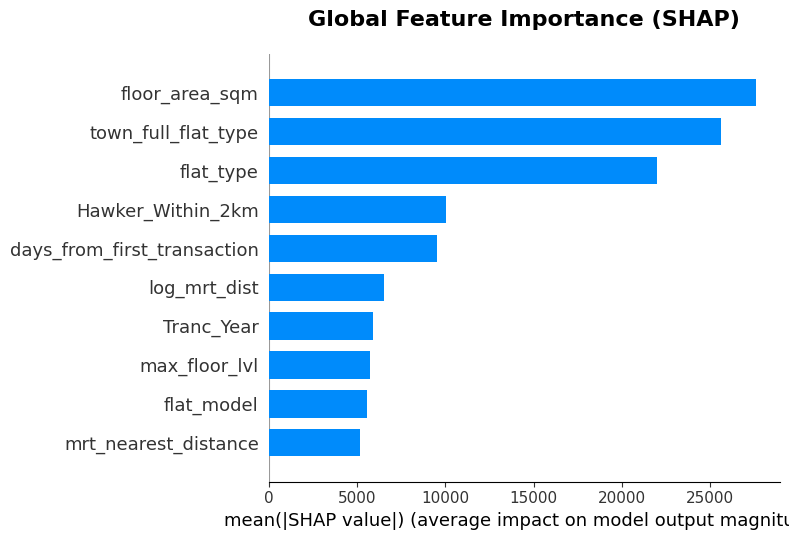

CatBoost Feature Importance Rankings (Top 10):
Rank  Feature                                             Importance
----------------------------------------------------------------------
1     town_full_flat_type                                       23.5
2     floor_area_sqm                                             9.8
3     flat_type                                                  5.9
4     days_from_first_transaction                                5.1
5     flat_model                                                 3.8
6     Hawker_Within_2km                                          3.5
7     Tranc_Year                                                 2.9
8     max_floor_lvl                                              2.5
9     log_mrt_dist                                               2.3
10    hdb_age                                                    2.3


,Feature,SHAP_MeanAbs,CatBoost_Importance
0,floor_area_sqm,27565.655049,9.757257
1,town_full_flat_type,25614.328056,23.498288
2,flat_type,21997.067776,5.941290
3,Hawker_Within_2km,10033.811193,3.536211
4,days_from_first_transaction,9534.732924,5.088317
5,log_mrt_dist,6507.607356,2.345856
6,Tranc_Year,5912.602420,2.874743
7,max_floor_lvl,5717.313331,2.456400
8,flat_model,5587.743945,3.785327
9,mrt_nearest_distance,5196.290116,1.650370


In [20]:
# SHAP explanations on the held-out X_test using the tuned (not final) pipeline,
# so that interpretation references a model that has NOT seen the test rows.
import shap
import matplotlib.pyplot as plt

interp_pipeline = best_catboost_pipeline
final_model = interp_pipeline.named_steps['model']

# Recover the preprocessed feature names from the fitted ColumnTransformer.
# Cat columns come first, then passthrough numerics.
preprocessed_feature_names = list(
    interp_pipeline.named_steps['preprocessor'].get_feature_names_out()
)
# Strip the 'cat__' / 'remainder__' prefixes sklearn adds for cleaner labels.
preprocessed_feature_names = [
    name.split('__', 1)[-1] for name in preprocessed_feature_names
]

shap_sample_size = min(2000, len(X_test))
X_shap_raw = X_test.sample(n=shap_sample_size, random_state=42)
X_shap_transformed = interp_pipeline[:-1].transform(X_shap_raw)
X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=preprocessed_feature_names,
    index=X_shap_raw.index,
)

X_shap_pool = Pool(
    X_shap_df,
    cat_features=cat_feature_indices,
)

explainer = shap.TreeExplainer(final_model)

print('Calculating SHAP values...')
shap_values = explainer.shap_values(X_shap_pool)
print(f'SHAP values calculated for {shap_values.shape[0]} predictions')
print(f'Each prediction explained by {shap_values.shape[1]} transformed features')

catboost_importance = final_model.get_feature_importance()
shap_importance_values = np.mean(np.abs(shap_values), axis=0)

shap_importance = (
    pd.DataFrame({
        'Feature': preprocessed_feature_names,
        'SHAP_MeanAbs': shap_importance_values,
        'CatBoost_Importance': catboost_importance,
    })
    .sort_values('SHAP_MeanAbs', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap_df,
    feature_names=preprocessed_feature_names,
    plot_type='bar',
    max_display=10,
    show=False,
)
plt.title('Global Feature Importance (SHAP)', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print('CatBoost Feature Importance Rankings (Top 10):')
print('=' * 70)
print(f"{'Rank':<6}{'Feature':<50}{'Importance':>12}")
print('-' * 70)
catboost_ranking = shap_importance.sort_values('CatBoost_Importance', ascending=False).head(10).reset_index(drop=True)
for rank, row in catboost_ranking.iterrows():
    feature = row['Feature']
    if len(feature) > 47:
        feature = feature[:44] + '...'
    print(f"{rank + 1:<6}{feature:<50}{row['CatBoost_Importance']:>12.1f}")

shap_importance.head(30)


## Appendix — Retired Scaler Code (reference only)

CatBoost is tree-based and invariant to monotonic transforms of numeric features, so StandardScaler/MinMaxScaler add cost without accuracy benefit. The scaler-based preprocessor is retained below, commented out, in case the same feature engineering is later reused with a linear/distance-based model that does benefit from scaling.


In [ ]:
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
#
# std_scale_cols = [
#     'floor_area_sqm',
#     'Mall_Nearest_Distance',
#     'Hawker_Nearest_Distance',
#     'mrt_nearest_distance',
#     'bus_stop_nearest_distance',
#     'pri_sch_nearest_distance',
#     'sec_sch_nearest_dist',
#     'days_from_first_transaction',
#     'month_sin',
#     'month_cos',
#     'remaining_lease',
#     'property_age_at_sale',
#     'storey_mid_ratio',
#     'log_mrt_dist',
#     'log_mall_dist',
#     'log_hawker_dist',
#     'log_bus_dist',
#     'log_pri_sch_dist',
#     'log_sec_sch_dist',
#     'accessibility_score',
#     'geo_cluster_prob',
# ]
#
# minmax_scale_cols = [
#     '1room_sold',
#     'bus_interchange',
#     'mrt_interchange',
#     'pri_sch_affiliation',
#     'affiliation',
#     'lease_commence_date',
#     'Tranc_Year',
#     'Tranc_Month',
#     'mid_storey',
#     'lower',
#     'upper',
#     'mid',
#     'hdb_age',
#     'max_floor_lvl',
#     'year_completed',
#     'total_dwelling_units',
#     '2room_sold',
#     '3room_sold',
#     '4room_sold',
#     '5room_sold',
#     'exec_sold',
#     'multigen_sold',
#     'studio_apartment_sold',
#     '1room_rental',
#     '2room_rental',
#     '3room_rental',
#     'other_room_rental',
#     'Mall_Within_500m',
#     'Mall_Within_1km',
#     'Mall_Within_2km',
#     'Hawker_Within_500m',
#     'Hawker_Within_1km',
#     'Hawker_Within_2km',
#     'hawker_food_stalls',
#     'hawker_market_stalls',
#     'vacancy',
#     'cutoff_point',
#     'transaction_quarter',
#     'is_new_flat',
#     'is_old_flat',
#     'flat_type_ordinal',
#     'mrt_walkable',
#     'bus_walkable',
#     'mall_walkable',
#     'hawker_walkable',
#     'pri_school_walkable',
#     'sec_school_walkable',
#     'integrated_transport_access',
#     'geo_noise_flag',
# ]
#
# std_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#     ('scaler', StandardScaler()),
# ])
#
# minmax_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#     ('scaler', MinMaxScaler()),
# ])
#
# scaled_preprocessor = ColumnTransformer(transformers=[
#     ('std', std_pipeline, std_scale_cols),
#     ('minmax', minmax_pipeline, minmax_scale_cols),
#     ('cat', categorical_pipeline, catboost_categorical_cols),
# ])
#
# # If reused, recompute cat_feature_indices to match this column order:
# # scaled_preprocessed_feature_names = std_scale_cols + minmax_scale_cols + catboost_categorical_cols
# # scaled_cat_feature_indices = list(range(
# #     len(std_scale_cols) + len(minmax_scale_cols),
# #     len(scaled_preprocessed_feature_names),
# # ))
